In [1]:
# ============================================================
# NOTEBOOK 01 — EDA AND DATA UNDERSTANDING
# ============================================================
# Purpose:
#   Explore the raw Mental Health in Tech 2016 dataset and gather
#   the evidence needed for preprocessing, feature engineering,
#   dimensionality reduction, and clustering decisions.
#
# Case Study:
#   DLBDSMLUSL01 — Task 1
#   Mental Health in Technology-related Jobs
#
# Principle:
#   observation -> investigation -> finding -> implication
#   The raw dataset is never modified in this notebook.
# ============================================================

# 1. Purpose and Case Study Context

This notebook performs the initial exploratory data analysis (EDA) and data understanding for the **Mental Health in Technology-related Jobs** case study.

The purpose of this stage is to understand the structure, quality, completeness, and meaning of the survey data before making decisions about preprocessing, feature engineering, dimensionality reduction, and clustering.

## The analysis focuses on identifying:

 - the size and structure of the dataset;
 - missing and conditionally missing values;
 - the way survey routing affects missingness;
 - variable types, cardinality, and response structures;
 - potential data-quality problems;
 - the population represented by the survey;
 - the meaning of important response categories;
 - geographic structure;
 - the usability of free-text responses; and
 - potentially redundant or strongly associated categorical variables.
 
The EDA is deliberately exploratory. Observations are first identified and, where necessary, tested with additional analyses before they are treated as findings. This distinction is important because decisions made in later preprocessing and modeling stages should be supported by evidence from the data rather than assumptions about the survey.

## The analysis therefore follows the progression:

**observation → investigation → finding → implication for later processing**

The findings from this notebook will be used to determine which variables and observations require treatment in the subsequent preprocessing and feature-engineering stages.

# 2. Imports and Configuration

This cell sets up the notebook environment.

**Project bootstrap**  
Because the notebooks live in the `notebooks/` subdirectory, we first ensure the project root is on `sys.path`. This makes the local `src/` package importable with clean statements such as `from src.plotting import …`.

**Local helpers**  
- `src.plotting` provides a consistent colour palette (`PALETTE`), a one-call style configuration (`apply_style()`), and a path-safe figure saver (`save_figure`).  
- `src.io_utils` provides a matching helper (`save_csv`) that writes processed dataframes to `data/processed/`.

**Third-party libraries**  
Standard tools for data handling (`pandas`, `numpy`), statistical tests (`scipy.stats.chi2_contingency` for later Cramér’s V analysis), and visualisation (`matplotlib`, `seaborn`) are imported next.

**Display & style settings**  
Pandas display options are relaxed so wide tables remain readable, and `apply_style()` applies a uniform set of Matplotlib/Seaborn rcParams (DPI, spines, grid, colours) across every notebook in the project.

No data are loaded or transformed in this section; the raw survey file remains untouched.

In [2]:
# Cell 1: Imports, display settings, and figure-saving helper

# --- Project bootstrap: make `src/` importable from notebooks/ ---
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# --- Local package ---
from src.plotting import save_figure, apply_style, PALETTE
from src.io_utils import save_csv

# --- Data manipulation ---
import pandas as pd
import numpy as np

# --- Statistics (Cramér's V association analysis, Section 12) ---
from scipy.stats import chi2_contingency

# --- Visualisation ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Display settings ---
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)
apply_style()  # sets dpi, spines, grid, colours

print("All imports successful.")
print(f"Project root: {PROJECT_ROOT}")

All imports successful.
Project root: /home/massaquoi/projects/iu-mental-health-tech-clustering-caseStudy


# 3. Load Raw Dataset

In [3]:
# Cell 2: Load raw data


from src.paths import DATA_RAW

RAW_PATH = DATA_RAW / "mental-health-in-tech-2016.csv"

df = pd.read_csv(RAW_PATH)

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Source: {RAW_PATH}")

Dataset loaded: 1,433 rows × 63 columns
Source: /home/massaquoi/projects/iu-mental-health-tech-clustering-caseStudy/data/raw/mental-health-in-tech-2016.csv


# 4. Dataset Overview

Before investigating individual variables, the overall structure of the dataset is examined.

This section establishes the basic characteristics of the survey data, including:

- the number of observations and variables;
- the names of the available variables;
- the storage data types reported by pandas; and
- whether exact duplicate rows are present.

The purpose is to establish a structural baseline for the dataset before examining missingness, response categories, and individual variables in greater detail.

At this stage, the reported pandas data types should not automatically be interpreted as the substantive type of a variable. For example, survey responses stored as `object` may represent binary, ordinal, nominal, multi-label, or free-text responses. Their actual analytical structure is investigated later in the notebook.

In [4]:
# Cell 3: Column inventory
# Print all column names with their index so I can reference them easily later.

for i, col in enumerate(df.columns):
    print(f"{i:>3}  {col}")

  0  Are you self-employed?
  1  How many employees does your company or organization have?
  2  Is your employer primarily a tech company/organization?
  3  Is your primary role within your company related to tech/IT?
  4  Does your employer provide mental health benefits as part of healthcare coverage?
  5  Do you know the options for mental health care available under your employer-provided coverage?
  6  Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?
  7  Does your employer offer resources to learn more about mental health concerns and options for seeking help?
  8  Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?
  9  If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:
 10  Do you think that discussing a mental health disorder with your employer w

In [5]:
# Cell 4: Data types and non-null counts
# df.info() gives a quick overview of each column's dtype and how many
# non-null values it contains — useful for spotting heavily missing columns.

df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   str    
 2   Is your employer primarily a tech company/organization?                

In [6]:
# Cell 5: Check for duplicate rows
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes}")

Duplicate rows: 0


In [7]:
#cell 5.1: Perform some basic summary statistics on the dataset 

df.describe(include='all')

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

In [8]:
# Cell 5.2: Check concise summary of a Dataset

df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 1433 entries, 0 to 1432
Data columns (total 63 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Are you self-employed?                                                                                                                                                            1433 non-null   int64  
 1   How many employees does your company or organization have?                                                                                                                        1146 non-null   str    
 2   Is your employer primarily a tech company/organization?                

# 5. Missingness Analysis

Missing values are investigated before any preprocessing decision is made because missingness in a survey dataset does not necessarily indicate poor data quality.

In a questionnaire, some questions may only be shown to respondents who selected particular answers to earlier questions. Consequently, a missing value can represent a deliberate survey-routing outcome rather than a missing response that should be imputed.

This section first establishes the overall amount of missing data and then examines columns with no observed values and columns with complete responses.

The missingness structure is subsequently visualized in a way that makes the major respondent groups and survey-routing patterns easier to identify.

The objective is therefore not simply to count missing values, but to determine whether missingness appears to follow meaningful structures that need to be considered during preprocessing.

In [9]:
# Cell 6: Missing value table — count and percentage per column

missing = (
    pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_pct":   df.isnull().mean() * 100
    })
    .sort_values("missing_pct", ascending=False)
)

print(missing.to_string())

                                                                                                                                                                                  missing_count  missing_pct
If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?                                                               1289    89.951151
If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?                                                       1229    85.764131
Is your primary role within your company related to tech/IT?                                                                                                                               1170    81.646895
Do you have medical coverage (private insurance or state-provided) which includes treatment of  mental health issues?                                                               

## 5.1 Routing-Aware Missingness Visualization

The missingness pattern is visualized after ordering observations according to the survey-routing variables investigated in the following section.

This ordering makes it easier to determine whether blocks of missing responses correspond to identifiable respondent groups rather than occurring randomly throughout the dataset. 
The visualization is therefore used as supporting evidence for the missingness investigation rather than as a preprocessing step itself.


In [10]:
# Cell 7: Column-name constants used throughout the notebook
# The survey questions are long, so each column that is analysed more than once
# is assigned a short constant here. This avoids typing errors and keeps later
# cells readable. Names must match the CSV headers exactly.

# Routing gates (determine which question blocks a respondent saw)
SELF = "Are you self-employed?"
PREV = "Do you have previous employers?"

# Questions affected by routing
EMPL = "How many employees does your company or organization have?"
TECH = "Is your employer primarily a tech company/organization?"
ROLE = "Is your primary role within your company related to tech/IT?"
PREVB = "Have your previous employers provided mental health benefits?"

# Personal mental-health backbone
CUR = "Do you currently have a mental health disorder?"
PAST = "Have you had a mental health disorder in the past?"
FAMILY = "Do you have a family history of mental illness?"
CAREER = ("Do you feel that being identified as a person with a mental health "
          "issue would hurt your career?")

# Response-semantics and ordinal candidates
INTERF_T = ("If you have a mental health issue, do you feel that it interferes "
            "with your work when being treated effectively?")
INTERF_U = ("If you have a mental health issue, do you feel that it interferes "
            "with your work when NOT being treated effectively?")
LEAVE = ("If a mental health issue prompted you to request a medical leave "
         "from work, asking for that leave would be:")
SHARE = ("How willing would you be to share with friends and family that you "
         "have a mental illness?")
PCT_AFFECTED = ("If yes, what percentage of your work time (time performing "
                "primary or secondary job functions) is affected by a mental "
                "health issue?")

# Not explained by routing
UNSUP = ("Have you observed or experienced an unsupportive or badly handled "
         "response to a mental health issue in your current or previous workplace?")

# Demographics and geography
AGE = "What is your age?"
GEN = "What is your gender?"
LIVE = "What country do you live in?"
WORK = "What country do you work in?"

# Multi-label columns
POS = "Which of the following best describes your work position?"
COND = [
    "If yes, what condition(s) have you been diagnosed with?",
    "If maybe, what condition(s) do you believe you have?",
    "If so, what condition(s) were you diagnosed with?",
]

# Free-text columns (pandas renames the duplicate header to "Why or why not?.1")
FREE_TEXT_COLS = [c for c in df.columns if c.startswith("Why or why not?")]

# Fail early if any constant does not match a real column
all_constants = [SELF, PREV, EMPL, TECH, ROLE, PREVB, CUR, PAST, FAMILY, CAREER,
                 INTERF_T, INTERF_U, LEAVE, SHARE, PCT_AFFECTED, UNSUP, AGE,
                 GEN, LIVE, WORK, POS] + COND
missing_names = [c for c in all_constants if c not in df.columns]
print("Constants not found in dataframe:", missing_names)
print("Free-text columns:", FREE_TEXT_COLS)


Constants not found in dataframe: []
Free-text columns: ['Why or why not?', 'Why or why not?.1']


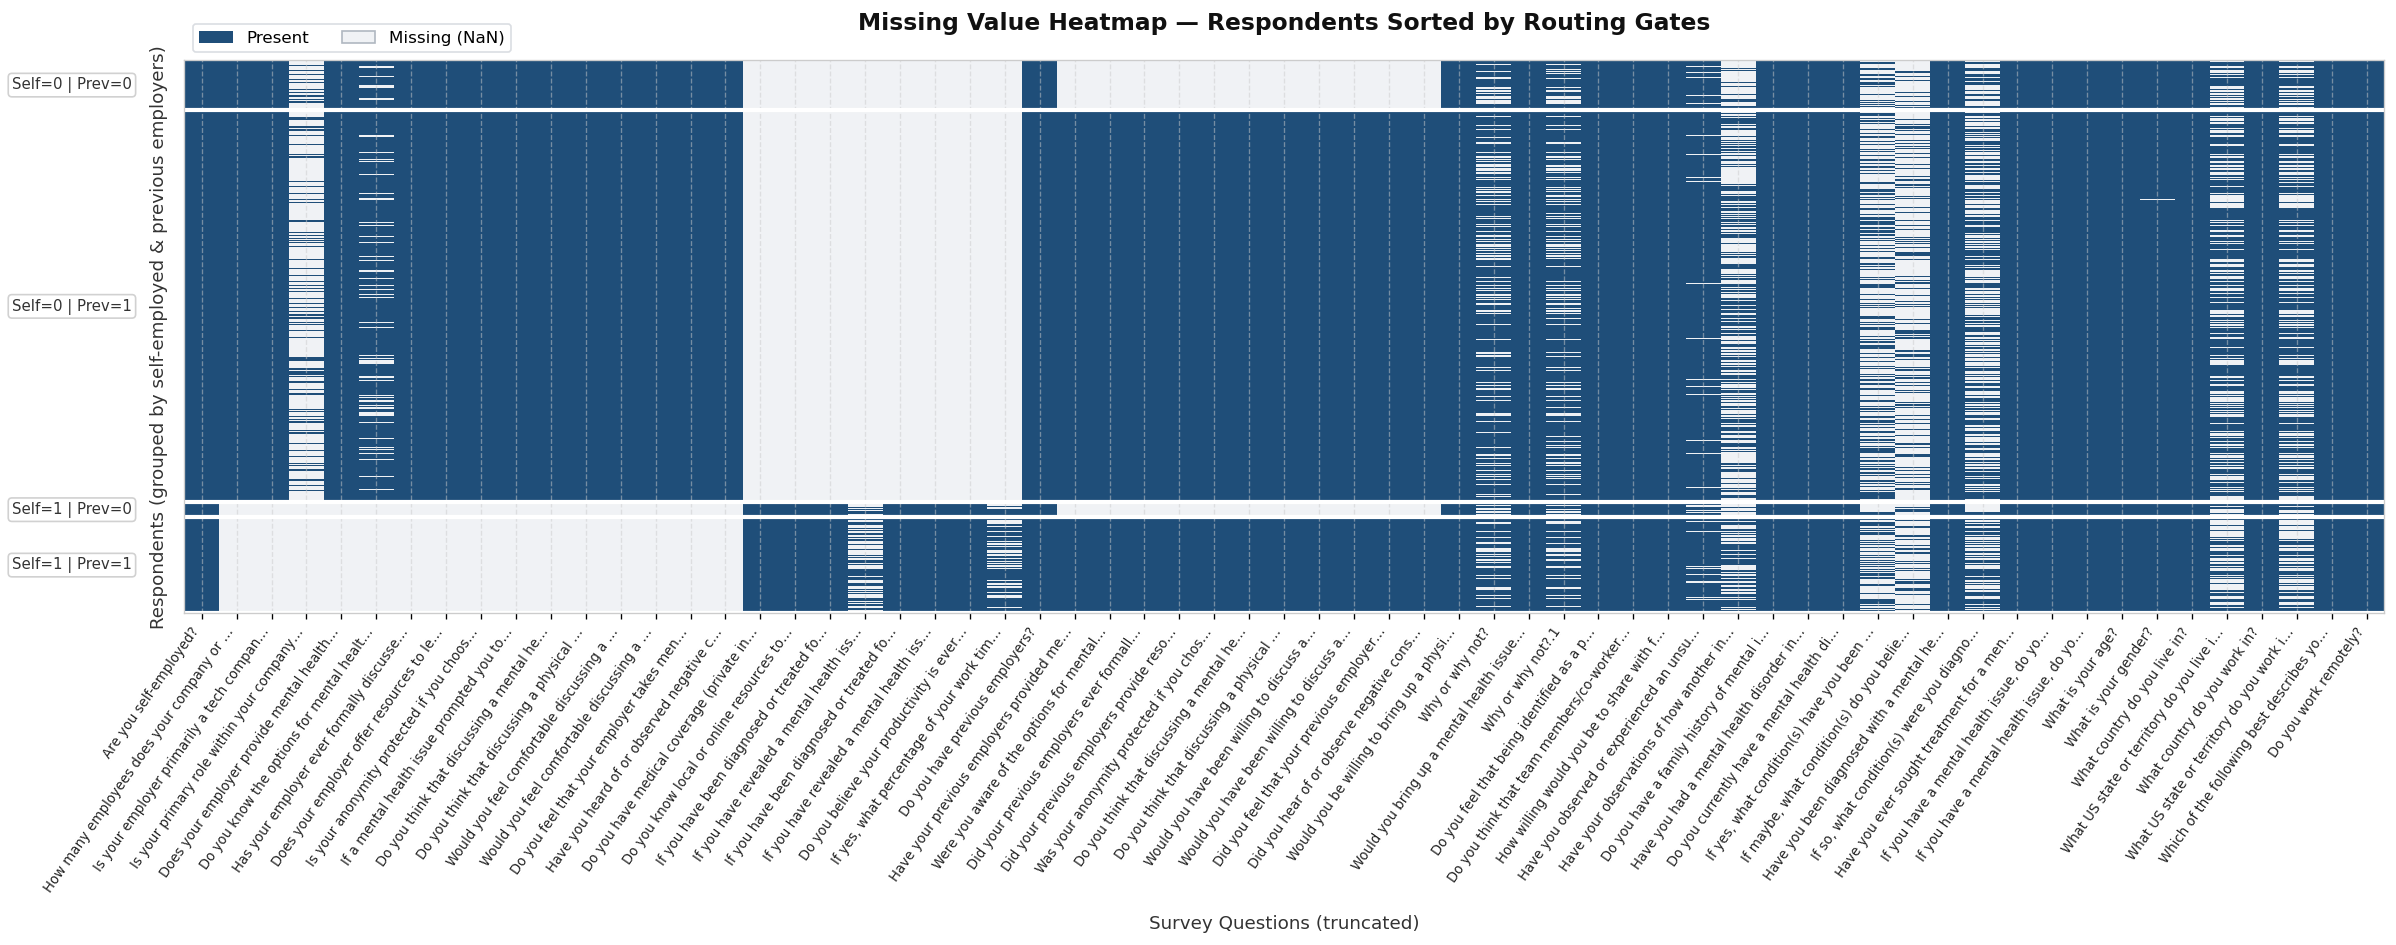

In [11]:
# Cell 8: Improved missing-value heatmap (sorted by routing gates)
# Goal: make the structural missingness easy to see and interpret

df_sorted = df.sort_values([SELF, PREV]).reset_index(drop=True)

# --- Build readable (short) column labels ---
# Keep first 40 characters + "…" so labels stay legible
short_labels = [
    (col[:40] + "…") if len(col) > 40 else col
    for col in df_sorted.columns
]

cmap = sns.color_palette([PALETTE["missing"], PALETTE["primary"]], as_cmap=True)

fig, ax = plt.subplots(figsize=(20, 8))

sns.heatmap(
    df_sorted.notnull(),
    cbar=False,
    yticklabels=False,
    cmap=cmap,
    ax=ax
)

# Cleaner x-axis labels
ax.set_xticks(np.arange(df_sorted.shape[1]) + 0.5)
ax.set_xticklabels(short_labels, rotation=55, ha="right", fontsize=8, color="#222222")

# Title & axis labels
ax.set_title("Missing Value Heatmap — Respondents Sorted by Routing Gates",
             fontsize=14, fontweight="bold", pad=18, color="#111111")
ax.set_xlabel("Survey Questions (truncated)", fontsize=11, labelpad=12, color="#333333")
ax.set_ylabel("Respondents (grouped by self-employed & previous employers)",
              fontsize=11, labelpad=10, color="#333333")

# --- Highlight the four routing groups with horizontal lines + labels ---
# Count how many respondents fall into each combination of the two gates
group_sizes = (
    df_sorted.groupby([SELF, PREV], dropna=False)
    .size()
    .reindex(pd.MultiIndex.from_product(
        [df_sorted[SELF].dropna().unique(), df_sorted[PREV].dropna().unique()]
    ), fill_value=0)
)

# Draw separator lines and annotate each block
y_pos = 0
for (self_val, prev_val), size in group_sizes.items():
    if size == 0:
        continue
    # light horizontal line at the bottom of the group
    ax.axhline(y_pos + size, color="white", linewidth=2.5)
    
    # short group label on the left
    label = f"Self={self_val} | Prev={prev_val}"
    ax.text(
        -1.5, y_pos + size / 2,
        label,
        va="center", ha="right",
        fontsize=9, fontweight="medium", color="#333333",
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#cccccc", alpha=0.9)
    )
    y_pos += size

# Legend
present_patch = plt.Rectangle((0, 0), 1, 1, facecolor=PALETTE["primary"], label="Present")
missing_patch = plt.Rectangle((0, 0), 1, 1, facecolor=PALETTE["missing"],
                              edgecolor="#b0b8c1", linewidth=1, label="Missing (NaN)")
ax.legend(
    handles=[present_patch, missing_patch],
    loc="upper left",
    bbox_to_anchor=(0.0, 1.08),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="#d1d5db",
    fontsize=10
)

# Subtle frame
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color(PALETTE["grid"])

plt.tight_layout()
save_figure(fig, "01_missing_heatmap_sorted.png")
plt.show()
plt.close(fig)

### 5.2 Interpretation of Second-Tier Routing

The analysis systematically searches for categorical questions that act as perfect “gates” for every partially-missing column. A gate is considered perfect when, within every value of that gate, the follow-up question is either always answered or always missing.

#### 1. Primary routing (already known)

| Gate question                        | Effect |
|--------------------------------------|--------|
| **Are you self-employed?**           | Self-employed respondents never see any of the current-employer questions. |
| **Do you have previous employers?**  | Respondents who answer “No” never see the entire previous-employer block. |

These two gates produce the large rectangular missing blocks visible in the sorted heatmap.

#### 2. Clean second-tier (nested) routing

| Follow-up question | Perfect gate | Meaning |
|--------------------|--------------|---------|
| Is your primary role within your company related to tech/IT? | Is your employer primarily a tech company/organization? | Asked only when the employer is **not** primarily a tech company (263 of 1,146 employed respondents). |
| If yes, what percentage of your work time… is affected? | Do you believe your productivity is ever affected by a mental health issue? | Only asked when the respondent said “Yes”. |
| All “previous employers …” questions | Do you have previous employers? | Only asked when the respondent had previous employers. |

#### 3. Apparent gates that are not real decisions

Many columns appear in the “perfect gates” list simply because they belong to the same survey block and therefore share an almost identical missingness pattern. These are **not** decision questions; they are just co-missing.

#### 4. Questions with no perfect gate among the tested candidates
Eleven columns have no perfect gate among candidates with at most 8 categories. This does not show that their missingness is random. Cell 8c tests five of them directly and confirms that they are gated: the two US-state questions by country (answered by exactly the US residents and the US workplaces), and the three condition questions by the disorder-status answers. For the condition questions, 7, 5 and 5 eligible respondents (1.2%, 1.5% and 0.7%) left the follow-up blank. The remaining six columns have no identified gate: the coverage-options question, the client-impact follow-up, the two "Why or why not?" fields, the unsupportive-response question, and the observation follow-up.

#### Summary

The survey implements a clear hierarchical skip pattern:

1. Self-employed status → hides the entire current-employer block.  
2. Previous-employer status → hides the entire previous-employer block.  
3. A small number of nested questions are shown only after a particular answer to their parent question: the tech-role question after “not a tech employer”, and the productivity-percentage question after “Yes” to the productivity question.

This structural missingness is intentional and must be respected in later preprocessing and modelling steps.

In [12]:
# Cell 8b: Second-tier routing — find the question that gates each follow-up
# For every column with partial missingness, look for a categorical column whose
# value perfectly predicts whether the follow-up was answered (NaN share is
# exactly 0 or 1 within every value of the candidate gate).

candidates = [c for c in df.columns
              if df[c].nunique() <= 8 and c not in FREE_TEXT_COLS]

partial = [c for c in df.columns if 0.01 < df[c].isna().mean() < 0.99]

for col in partial:
    gates = []
    for g in candidates:
        if g == col or df[g].isna().equals(df[col].isna()):
            continue  # skip itself and columns with an identical NaN pattern
        share = df[col].isna().groupby(df[g].fillna("__NaN__")).mean()
        if share.isin([0.0, 1.0]).all():
            gates.append(g[:60])
    print(f"{col[:70]}\n   perfect gates: {gates if gates else 'none found'}\n")

How many employees does your company or organization have?
   perfect gates: ['Are you self-employed?', 'Do you have medical coverage (private insurance or state-pro', 'Do you know local or online resources to seek help for a men', 'If you have been diagnosed or treated for a mental health di', 'If you have been diagnosed or treated for a mental health di', 'If you have revealed a mental health issue to a coworker or ', 'Do you believe your productivity is ever affected by a menta']

Is your employer primarily a tech company/organization?
   perfect gates: ['Are you self-employed?', 'Do you have medical coverage (private insurance or state-pro', 'Do you know local or online resources to seek help for a men', 'If you have been diagnosed or treated for a mental health di', 'If you have been diagnosed or treated for a mental health di', 'If you have revealed a mental health issue to a coworker or ', 'Do you believe your productivity is ever affected by a menta']

Is your primary role with

In [13]:
# Cell 8c: Direct tests of the follow-ups with no perfect gate in Cell 8b
# (a) US state questions: expected to depend on country (too many categories for Cell 8b).
# (b) Condition questions: expected to depend on the disorder-status answer.

STATE_LIVE = "What US state or territory do you live in?"
STATE_WORK = "What US state or territory do you work in?"
USA = "United States of America"
DIAG = "Have you been diagnosed with a mental health condition by a medical professional?"

print("--- Lives in USA vs state-of-residence missing ---")
print(pd.crosstab(df[LIVE] == USA, df[STATE_LIVE].isna(),
                  rownames=["lives_in_USA"], colnames=["state_NaN"]))

print("\n--- Works in USA vs state-of-work missing ---")
print(pd.crosstab(df[WORK] == USA, df[STATE_WORK].isna(),
                  rownames=["works_in_USA"], colnames=["state_NaN"]))

print("\n--- Current disorder == Yes vs 'diagnosed with' answered ---")
print(pd.crosstab(df[CUR], df[COND[0]].isna(),
                  rownames=["current_disorder"], colnames=["condition_NaN"]))

print("\n--- Current disorder == Maybe vs 'believe you have' answered ---")
print(pd.crosstab(df[CUR], df[COND[1]].isna(),
                  rownames=["current_disorder"], colnames=["condition_NaN"]))

print("\n--- Diagnosed by professional vs 'were you diagnosed with' answered ---")
print(pd.crosstab(df[DIAG], df[COND[2]].isna(),
                  rownames=["diagnosed_by_professional"], colnames=["condition_NaN"]))

--- Lives in USA vs state-of-residence missing ---
state_NaN     False  True 
lives_in_USA              
False             0    593
True            840      0

--- Works in USA vs state-of-work missing ---
state_NaN     False  True 
works_in_USA              
False             0    582
True            851      0

--- Current disorder == Yes vs 'diagnosed with' answered ---
condition_NaN     False  True 
current_disorder              
Maybe                 0    327
No                    0    531
Yes                 568      7

--- Current disorder == Maybe vs 'believe you have' answered ---
condition_NaN     False  True 
current_disorder              
Maybe               322      5
No                    0    531
Yes                   0    575

--- Diagnosed by professional vs 'were you diagnosed with' answered ---
condition_NaN              False  True 
diagnosed_by_professional              
No                             0    717
Yes                          711      5


In [14]:
# Cell 9: Identify columns with no missing values
# These are always-answered questions — likely the backbone of any feature set.

zero_missing = missing[missing["missing_count"] == 0]
print(f"Columns with 0 missing values ({len(zero_missing)}):\n")
print(zero_missing.index.tolist())

Columns with 0 missing values (19):

['Are you self-employed?', 'Do you have previous employers?', 'Would you be willing to bring up a physical health issue with a potential employer in an interview?', 'Have you had a mental health disorder in the past?', 'Do you have a family history of mental illness?', 'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?', 'How willing would you be to share with friends and family that you have a mental illness?', 'Do you feel that being identified as a person with a mental health issue would hurt your career?', 'Would you bring up a mental health issue with a potential employer in an interview?', 'Have you been diagnosed with a mental health condition by a medical professional?', 'Do you currently have a mental health disorder?', 'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?', 'If you have a mental healt

In [15]:
# Cell 10: Identify columns that are entirely missing for this population
# 100%-missing columns are candidates for exclusion.

fully_missing = missing[missing["missing_pct"] == 100]
print(f"Columns with 100% missing ({len(fully_missing)}):\n")
print(fully_missing.index.tolist())

Columns with 100% missing (0):

[]


## 5.3 Survey Routing Validation

The previous section identified substantial patterns of missingness. However, the presence of a pattern alone does not establish why the values are missing.

This section therefore tests whether major blocks of missing responses correspond to the structure of the survey questionnaire.

The investigation focuses on three routing hypotheses:
 1. whether respondents who identified as self-employed were systematically excluded from employer-related questions;
 2. whether respondents without previous employers were systematically excluded from previous-employer questions; and
 3. whether responses concerning the employer's technology-related activities determine whether a subsequent technology-role question was answered.

Finally, missing values that cannot be explained by these routing relationships are examined separately.

This distinction is important because structurally missing responses and unexplained missing responses may require different treatment during preprocessing.

In [16]:
# Cell 11: Hypothesis 1 — self-employed respondents skip the employer block
# If the hypothesis holds, the employer question is missing exactly when
# self-employed == 1. The boolean below tests this for every respondent.

print("--- Self-employed vs employer block missing ---")
print(pd.crosstab(df[SELF], df[EMPL].isna(),
                  rownames=["self_employed"], colnames=["employer_block_NaN"]))

holds_h1 = ((df[SELF] == 1) == df[EMPL].isna()).all()
print(f"\nHypothesis 1 holds for every respondent: {holds_h1}")

--- Self-employed vs employer block missing ---
employer_block_NaN  False  True 
self_employed                   
0                    1146      0
1                       0    287

Hypothesis 1 holds for every respondent: True


In [17]:
# Cell 12: Hypothesis 2 — respondents without previous employers skip that block
# The previous-employer block is expected to be missing exactly when
# "Do you have previous employers?" == 0.

print("--- Has previous employers vs previous-employer block missing ---")
print(pd.crosstab(df[PREV], df[PREVB].isna(),
                  rownames=["has_prev_employers"], colnames=["prev_block_NaN"]))

holds_h2 = ((df[PREV] == 0) == df[PREVB].isna()).all()
print(f"\nHypothesis 2 holds for every respondent: {holds_h2}")

--- Has previous employers vs previous-employer block missing ---
prev_block_NaN      False  True 
has_prev_employers              
0                       0    169
1                    1264      0

Hypothesis 2 holds for every respondent: True


In [18]:
# Cell 13: Hypothesis 3 — the tech-role question is only asked for non-tech employers
# -1 marks respondents who never saw the employer-is-tech question (self-employed).
# Tech-role is expected to be answered only when employer_is_tech == 0.

print("--- Employer is tech vs tech-role question missing ---")
print(pd.crosstab(df[TECH].fillna(-1), df[ROLE].isna(),
                  rownames=["employer_is_tech (-1 = not asked)"],
                  colnames=["tech_role_NaN"]))

holds_h3 = ((df[TECH] == 0) == df[ROLE].notna()).all()
print(f"\nHypothesis 3 holds for every respondent: {holds_h3}")

--- Employer is tech vs tech-role question missing ---
tech_role_NaN                      False  True 
employer_is_tech (-1 = not asked)              
-1.0                                   0    287
 0.0                                 263      0
 1.0                                   0    883

Hypothesis 3 holds for every respondent: True


In [19]:
# Cell 14: Missingness not explained by the routing gates
# The "unsupportive response" question (89 NaN) and Gender (3 NaN) are not gated
# by any routing variable. Cross-tabulate against both gates to see who they are.

print("--- 'Unsupportive response' NaN by (self-employed, has previous employers) ---")
print(df.loc[df[UNSUP].isna(), [SELF, PREV]].value_counts())

print("\n--- Gender NaN by (self-employed, has previous employers) ---")
print(df.loc[df[GEN].isna(), [SELF, PREV]].value_counts())

--- 'Unsupportive response' NaN by (self-employed, has previous employers) ---
Are you self-employed?  Do you have previous employers?
0                       1                                  39
1                       1                                  23
                        0                                  14
0                       0                                  13
Name: count, dtype: int64

--- Gender NaN by (self-employed, has previous employers) ---
Are you self-employed?  Do you have previous employers?
0                       1                                  3
Name: count, dtype: int64


## 6. Variable Structure and Cardinality

The pandas data types identified earlier describe how variables are stored, but they do not fully describe how survey responses should be interpreted analytically.

This section therefore examines the number and structure of unique responses in each variable.

The analysis distinguishes between different response structures, including:
 - binary variables;
 - nominal categorical variables;
 - ordinal variables;
 - multi-label responses; and
 - free-text responses.

Cardinality is also examined because variables with only a few response categories behave differently from variables containing many distinct values.


This classification is important for later preprocessing because categorical, ordinal, multi-label, and textual variables cannot necessarily be represented or transformed in the same way for unsupervised learning.

In [20]:
# Cell 15: Number of unique values per column (sorted ascending)
# Columns with 2 unique values are likely binary.
# Columns with very high cardinality may be free text or identifiers.

unique_counts = df.nunique().sort_values()
print(unique_counts.to_string())

Are you self-employed?                                                                                                                                                                 2
Is your employer primarily a tech company/organization?                                                                                                                                2
Is your primary role within your company related to tech/IT?                                                                                                                           2
Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?                                                    2
Do you have previous employers?                                                                                                                                                        2
Do you have medical coverage (private insurance or state-provided) which in

In [21]:
# Cell 16: Value counts for columns with <= 6 unique values
# These are the cleanest categorical columns and form the core of the feature set.
# dropna=False keeps the NaN count visible next to each response.

low_card = [col for col in df.columns if df[col].nunique() <= 6]

for col in low_card:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False).to_string())


--- Are you self-employed? ---
Are you self-employed?
0    1146
1     287

--- How many employees does your company or organization have? ---
How many employees does your company or organization have?
26-100            292
NaN               287
More than 1000    256
100-500           248
6-25              210
500-1000           80
1-5                60

--- Is your employer primarily a tech company/organization? ---
Is your employer primarily a tech company/organization?
1.0    883
NaN    287
0.0    263

--- Is your primary role within your company related to tech/IT? ---
Is your primary role within your company related to tech/IT?
NaN    1170
1.0     248
0.0      15

--- Does your employer provide mental health benefits as part of healthcare coverage? ---
Does your employer provide mental health benefits as part of healthcare coverage?
Yes                                531
I don't know                       319
NaN                                287
No                               

In [22]:
# Cell 17: Sample values for columns with > 20 unique values
# These may require normalisation, grouping, or exclusion.

high_card = [col for col in df.columns if df[col].nunique() > 20]

for col in high_card:
    sample = df[col].dropna().unique()[:10]
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(sample)


--- Why or why not? (1085 unique) ---
<StringArray>
['It would depend on the health issue. If there is a health issue that would not immediately affect my job performance, such as diabetes, I would not bring it up during the interview. If it was something more severe, such as narcolepsy, I might bring it up depending on how controlled it was.',
                                                                                                                                                                                                                             'They would provable need to know, to Judge if I can do my job or not. ',
                                                                                                                                                                                                 'old back injury, doesn't cause me many issues but occasionally impacts my ability to work at desk ',
                                                              

## 7.0 Response-Type Taxonomy

The survey variables are examined and grouped according to the structure of their responses.

The categories used in this analysis include:
 - **Binary variables:** variables with two substantive response states;
 - **Categorical variables:** nominal responses where categories do not have a natural ordering;
 - **Ordinal variables:** responses whose categories have a meaningful order;
 - **Multi-label variables:** responses containing multiple selections within a single field; and
 - **Free-text variables:** open-ended responses expressed in natural language.

This taxonomy is descriptive at this stage. The actual encoding and transformation of these variables are deferred to the preprocessing and feature-engineering stages.

In [23]:
# Cell 18: Programmatic response-type taxonomy
# Rules are applied in order:
#   free text (by name)
#   -> ordinal candidates (manual)
#   -> multi-label ("|" in a meaningful share of responses)
#   -> binary
#   -> continuous numeric
#   -> low-cardinality categorical
#   -> everything else
# This is a descriptive label only — nothing is encoded.

ORDINAL_CANDIDATES = [INTERF_T, INTERF_U, LEAVE, SHARE, PCT_AFFECTED]


def classify_column(col):
    """Return a descriptive response-type label for one column."""
    s = df[col].dropna()

    if col in FREE_TEXT_COLS:
        return "free_text"

    if col in ORDINAL_CANDIDATES:
        return "ordinal_candidate (manual)"

    # Multi-label only if "|" appears in a meaningful share of responses.
    # A single stray "|" (e.g. the gender typo "M|") must not trigger it.
    if pd.api.types.is_string_dtype(s):
        pipe_share = s.astype(str).str.contains("|", regex=False).mean()
        if pipe_share >= 0.05:
            return "multi_label"

    n_unique = s.nunique()

    if n_unique == 2:
        return "binary"

    if pd.api.types.is_numeric_dtype(s) and n_unique > 20:
        return "numeric_continuous"

    if n_unique <= 8:
        return "categorical_low_cardinality"

    return "high_cardinality_other"


taxonomy = pd.DataFrame({
    "response_type": [classify_column(c) for c in df.columns],
    "n_unique": [df[c].nunique() for c in df.columns],
    "missing_pct": (df.isnull().mean() * 100).round(1).values,
}, index=df.columns)

print(taxonomy["response_type"].value_counts().to_string())
print()
for rtype, group in taxonomy.groupby("response_type"):
    print(f"\n=== {rtype} ({len(group)}) ===")
    print(group[["n_unique", "missing_pct"]].to_string())

response_type
categorical_low_cardinality    38
binary                          8
ordinal_candidate (manual)      5
high_cardinality_other          5
multi_label                     4
free_text                       2
numeric_continuous              1


=== binary (8) ===
                                                                                                                                     n_unique  missing_pct
Are you self-employed?                                                                                                                      2          0.0
Is your employer primarily a tech company/organization?                                                                                     2         20.0
Is your primary role within your company related to tech/IT?                                                                                2         81.6
Have you heard of or observed negative consequences for co-workers who have been open about mental health i

## 7.1 Multi-Label Variables

Several survey variables contain multiple responses within a single cell, separated by the `|` character.
Both the number of distinct raw combinations and the underlying individual labels are examined.

The raw combination count shows how respondents' selections are stored in the dataset, while exploding the values provides a clearer view of the actual vocabulary represented by each multi-label variable.

This distinction is important because a large number of raw combinations does not necessarily mean that the underlying variable contains an equally large number of substantive categories.

In [24]:
# Cell 19: Explode pipe-separated columns into label vocabularies
# Split each cell on "|", flatten, and count each label across respondents.
# Compare the number of distinct labels with the number of raw combinations.


def explode_counts(col):
    """Return label frequencies after splitting a pipe-separated column."""
    return (
        df[col].dropna()
        .str.split("|")
        .explode()
        .str.strip()
        .value_counts()
    )


pos_counts = explode_counts(POS)
print(f"Work position: {df[POS].nunique()} raw combinations "
      f"-> {len(pos_counts)} distinct labels")
print(pos_counts.to_string())

for col in COND:
    counts = explode_counts(col)
    print(f"\n{col}")
    print(f"  {df[col].nunique()} raw combinations -> {len(counts)} distinct labels")
    print(counts.head(15).to_string())

Work position: 264 raw combinations -> 12 distinct labels
Which of the following best describes your work position?
Back-end Developer         737
Front-end Developer        502
DevOps/SysAdmin            282
Supervisor/Team Lead       277
Other                      187
Support                    168
One-person shop            161
Designer                   135
Executive Leadership       101
Dev Evangelist/Advocate     99
Sales                       31
HR                          12

If yes, what condition(s) have you been diagnosed with?
  128 raw combinations -> 33 distinct labels
If yes, what condition(s) have you been diagnosed with?
Mood Disorder (Depression, Bipolar Disorder, etc)               412
Anxiety Disorder (Generalized, Social, Phobia, etc)             345
Attention Deficit Hyperactivity Disorder                        121
Post-traumatic Stress Disorder                                   69
Obsessive-Compulsive Disorder                                    45
Substance Use 

## 7.2 Free-Text Variables

Open-ended questions are identified separately from structured categorical responses.

Their number of responses and distinct values are inspected to determine whether they are suitable for direct inclusion in the later unsupervised-learning pipeline or whether they should be excluded or transformed.

No textual transformation is performed in this EDA stage.

In [25]:
# Cell 20: Identify free-text columns and their basic cardinality
# A near one-to-one ratio of unique values to responses means the field behaves
# like free text rather than a categorical variable. Deeper assessment is in Section 11.

for col in FREE_TEXT_COLS:
    n_resp = df[col].notna().sum()
    n_uniq = df[col].nunique()
    print(f"{col}: {n_resp} responses, {n_uniq} unique "
          f"({n_uniq / n_resp * 100:.1f}% unique)")

Why or why not?: 1095 responses, 1085 unique (99.1% unique)
Why or why not?.1: 1126 responses, 1080 unique (95.9% unique)


## 7.3 Data Quality Investigation

This section examines variables where unusual responses, inconsistent representations, or implausible values could affect later analysis.

The investigation focuses on **Age** and **Gender** because both variables contain characteristics that require interpretation before they can be used reliably in subsequent modeling.

The objective is not to correct the data at this stage. Instead, the analysis identifies potential quality problems and records the evidence needed to justify later preprocessing decisions.

###  Age

Age is examined using descriptive statistics, targeted checks for suspicious values, and visualizations.

The descriptive statistics establish the central tendency and spread of the observed responses. Suspicious age ranges are then counted separately rather than being immediately removed.

This approach distinguishes between identifying potentially invalid observations and deciding how those observations should be handled.

A second visualization focuses on a plausible display range so that extreme values do not dominate the visual representation of the main respondent population.
The suspicious observations remain identifiable in the raw dataset and are not removed during EDA.

In [26]:
# Cell 21: Age descriptive statistics and suspicious-value bands
# Count respondents in each implausible band instead of removing them.
# Intervals are left-closed: [lo, hi).

age_series = df[AGE].dropna()

print("--- Age Summary Statistics ---")
print(age_series.describe())

print("\n--- Suspicious age bands (count of respondents) ---")
bands = [(0, 15), (15, 18), (70, 100), (100, 400)]
for lo, hi in bands:
    n = age_series.between(lo, hi, inclusive="left").sum()
    print(f"Age in [{lo}, {hi}): {n}")

--- Age Summary Statistics ---
count    1433.000000
mean       34.286113
std        11.290931
min         3.000000
25%        28.000000
50%        33.000000
75%        39.000000
max       323.000000
Name: What is your age?, dtype: float64

--- Suspicious age bands (count of respondents) ---
Age in [0, 15): 1
Age in [15, 18): 2
Age in [70, 100): 3
Age in [100, 400): 1


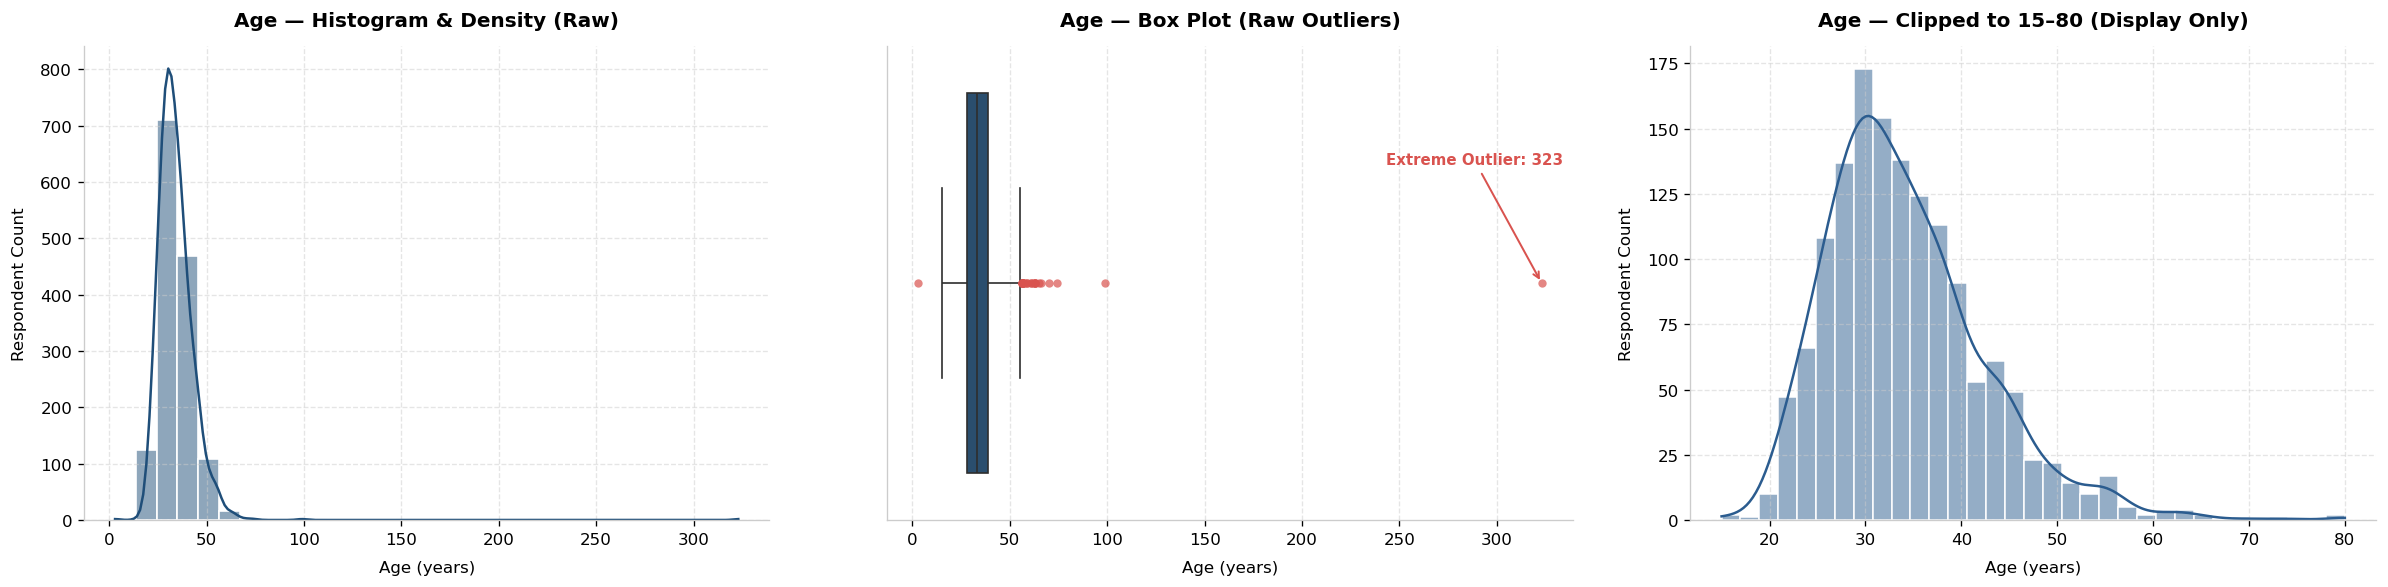

In [27]:
# Cell 22: Age distribution — raw view, outlier view, and clipped display view
# Panels 1 and 2 show the raw data including the extreme values.
# Panel 3 clips ages to 15-80 for DISPLAY ONLY so the main distribution is readable.
# The underlying data is not modified.

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Raw histogram + KDE
sns.histplot(age_series, bins=30, kde=True, color=PALETTE["primary"],
             edgecolor="#ffffff", ax=axes[0])
axes[0].set_title("Age — Histogram & Density (Raw)", fontsize=12,
                  fontweight="bold", pad=12)
axes[0].set_xlabel("Age (years)", fontsize=10, labelpad=8)
axes[0].set_ylabel("Respondent Count", fontsize=10, labelpad=8)

# 2. Raw box plot with outliers highlighted
sns.boxplot(
    x=age_series,
    color=PALETTE["primary"],
    fliersize=5,
    flierprops=dict(marker="o", markerfacecolor=PALETTE["accent"],
                    markeredgecolor="none", alpha=0.7),
    ax=axes[1]
)
axes[1].set_title("Age — Box Plot (Raw Outliers)", fontsize=12,
                  fontweight="bold", pad=12)
axes[1].set_xlabel("Age (years)", fontsize=10, labelpad=8)
axes[1].set_yticks([])  # remove the meaningless '1' tick of a single-variable boxplot

# Annotate the extreme value if one exists
max_age = age_series.max()
if max_age > 100:
    axes[1].annotate(
        f"Extreme Outlier: {int(max_age)}",
        xy=(max_age, 0),
        xytext=(max_age - 80, -0.25),
        arrowprops=dict(arrowstyle="->", color=PALETTE["accent"], lw=1.2),
        color=PALETTE["accent"],
        fontweight="bold",
        fontsize=9
    )

# 3. Clipped histogram (display only)
sns.histplot(age_series.clip(15, 80), bins=33, kde=True, color=PALETTE["secondary"],
             edgecolor="#ffffff", ax=axes[2])
axes[2].set_title("Age — Clipped to 15–80 (Display Only)", fontsize=12,
                  fontweight="bold", pad=12)
axes[2].set_xlabel("Age (years)", fontsize=10, labelpad=8)
axes[2].set_ylabel("Respondent Count", fontsize=10, labelpad=8)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_color(PALETTE["grid"])

plt.tight_layout()
save_figure(fig, "01_age_distribution.png")
plt.show()
plt.close(fig)

## 7.4 Gender
Gender responses are examined to understand the number and frequency of distinct raw categories.

The survey contains multiple representations, including differences in capitalization, spacing, abbreviations, alternative descriptions, and responses that do not correspond cleanly to a single standardized category.

These observations indicate that gender will require careful treatment if it is retained for later modeling.

At this stage, the raw responses are preserved rather than prematurely collapsing them into standardized categories.

In [28]:
# Cell 23: Gender raw categories and the effect of trivial normalisation
# The raw free-text field has many variants. Stripping spaces and lowercasing is a
# non-judgemental first step; the drop in distinct values shows how many variants
# are purely formatting. The normalised version is NOT stored — preview only.

gender_counts = df[GEN].value_counts(dropna=False)
print(f"Total unique raw Gender values: {df[GEN].nunique()}\n")
print(gender_counts.to_string())

normalised_preview = df[GEN].dropna().str.strip().str.lower()
print(f"\nUnique values after strip + lowercase only: {normalised_preview.nunique()}")

Total unique raw Gender values: 70

What is your gender?
Male                                                                                                                                                             610
male                                                                                                                                                             249
Female                                                                                                                                                           153
female                                                                                                                                                            95
M                                                                                                                                                                 86
m                                                                                                                     

# 8. Population and Survey Context
The survey contains respondents with different employment circumstances. Before defining the population for the clustering analysis, the relationship between self-employed and employed respondents is examined.

This section first compares the size of the two groups and then examines whether they share responses to key mental-health-related questions.

The purpose is to determine whether restricting the analysis to a particular employment group would substantially change the population being represented or whether important mental-health variables are available across both groups.

No population restriction is imposed solely from this EDA section. Any later decision about the analytical population must be supported by the evidence observed here and by the objectives of the case study.

### 8.1 Self-Employed vs Employed Respondents

The distribution of self-employed and employed respondents is examined to establish the composition of the survey population.

This is particularly relevant because several employer-related questions contain substantial missingness, and those missing values may be directly related to respondents' employment status.

In [29]:
# Cell 24: Self-employed vs employed split
# Self-employed respondents were routed through a different question branch.
# Counts and percentages are shown together so denominators are explicit.

print("--- Self-Employed Breakdown (counts) ---")
print(df[SELF].value_counts(dropna=False))

print("\n--- Percentage Breakdown ---")
print((df[SELF].value_counts(dropna=False, normalize=True) * 100).round(1))

--- Self-Employed Breakdown (counts) ---
Are you self-employed?
0    1146
1     287
Name: count, dtype: int64

--- Percentage Breakdown ---
Are you self-employed?
0    80.0
1    20.0
Name: proportion, dtype: float64


## 8.2 Shared Mental-Health Responses

Key mental-health-related questions that are available across employment groups are compared.

The purpose is to determine whether the groups share a common substantive response structure on the main mental-health dimensions represented in the survey.

In [30]:
# Cell 25: Self-employed vs employed on the shared backbone questions
# Row-normalised proportions show whether the two groups answer the always-asked
# questions differently. Large gaps would argue for treating them as separate populations.

for col in [CUR, PAST, FAMILY, CAREER]:
    print(f"\n--- {col} ---")
    print(pd.crosstab(df[SELF], df[col], normalize="index").round(3))


--- Do you currently have a mental health disorder? ---
Do you currently have a mental health disorder?  Maybe     No    Yes
Are you self-employed?                                              
0                                                0.222  0.385  0.394
1                                                0.254  0.314  0.432

--- Have you had a mental health disorder in the past? ---
Have you had a mental health disorder in the past?  Maybe     No    Yes
Are you self-employed?                                                 
0                                                   0.161  0.331  0.509
1                                                   0.216  0.251  0.533

--- Do you have a family history of mental illness? ---


Do you have a family history of mental illness?  I don't know     No    Yes
Are you self-employed?                                                     
0                                                       0.187  0.341  0.472
1                                                       0.213  0.338  0.449

--- Do you feel that being identified as a person with a mental health issue would hurt your career? ---
Do you feel that being identified as a person with a mental health issue would hurt your career?  Maybe  \
Are you self-employed?                                                                                    
0                                                                                                 0.412   
1                                                                                                 0.404   

Do you feel that being identified as a person with a mental health issue would hurt your career?  No, I don't think it would  \
Are you self-employed?           

In [31]:
# Cell 25b: Chi-square test of independence — employment group vs shared backbone questions
# A small p-value suggests the difference between groups is unlikely to be chance.
# Four tests are run, so a Bonferroni-adjusted threshold (0.05 / 4 = 0.0125) is also reported.
# Cramér's V is printed because with n = 1,433 even small differences can be significant.

for col in [CUR, PAST, FAMILY, CAREER]:
    table = pd.crosstab(df[SELF], df[col])
    chi2, p, dof, _ = chi2_contingency(table, correction=False)
    v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    print(f"{col[:70]}\n   chi2={chi2:.2f}, dof={dof}, p={p:.4f}, "
          f"Cramér's V={v:.3f}, significant after Bonferroni: {p < 0.05 / 4}\n")

Do you currently have a mental health disorder?
   chi2=5.07, dof=2, p=0.0794, Cramér's V=0.059, significant after Bonferroni: False

Have you had a mental health disorder in the past?
   chi2=9.03, dof=2, p=0.0110, Cramér's V=0.079, significant after Bonferroni: True

Do you have a family history of mental illness?
   chi2=1.05, dof=2, p=0.5903, Cramér's V=0.027, significant after Bonferroni: False

Do you feel that being identified as a person with a mental health iss
   chi2=1.39, dof=4, p=0.8461, Cramér's V=0.031, significant after Bonferroni: False



### 8.3 Population Implications
The findings from the employment-group comparison are considered in relation to the intended HR use case.

The analysis records what population is represented by the available data and identifies any implications that a later population restriction would have for interpretation and transferability of the clustering results.


**Group sizes.** Of the 1,433 respondents, 1,146 (80.0%) are employed and 287 (20.0%) are self-employed.

**Shared responses.** On the four questions answered by both groups, the distributions are similar. Chi-square tests of independence between employment group and each question gave p = 0.079 (current disorder), p = 0.011 (past disorder), p = 0.590 (family history), and p = 0.846 (career-related stigma). Only the past-disorder difference is significant at the 5% level, and it also remains significant after a Bonferroni correction for four tests (threshold 0.0125). All effect sizes are small (Cramér's V between 0.027 and 0.079). Self-employed respondents less often answered "No" to past disorder (25.1% vs 33.1%) and more often answered "Maybe". Family-history and stigma responses are statistically indistinguishable between the two groups.

**Implication.** The attitudes most relevant to the later clustering do not differ meaningfully between employed and self-employed respondents, so a restriction would not remove a group with a distinct attitudinal profile. The deciding consideration is structural: self-employed respondents were never shown the employer-related questions (Section 5.3, Cell 11), including benefits, available resources, anonymity protection, and leave. These are the variables most directly relevant to employer-side HR measures. Including the self-employed would require either excluding those variables from the clustering or carrying 287 respondents who are structurally missing all of them.

**Recommendation for Notebook 02.** Restrict the analytical population to employed respondents (n = 1,146). The exclusion of 287 self-employed respondents should be recorded as a limitation: the results describe employees rather than the full survey population, and the slightly lower share of "No" answers to past disorder among the self-employed is not represented.

In [32]:
# Cell 25c: Chi-square test of independence — self-employed vs shared backbone questions
# Small p-values suggest the difference between groups is unlikely to be chance.

for col in [CUR, PAST, FAMILY, CAREER]:
    table = pd.crosstab(df[SELF], df[col])
    chi2, p, dof, _ = chi2_contingency(table)
    print(f"{col[:70]}\n   chi2={chi2:.2f}, dof={dof}, p={p:.4f}\n")

Do you currently have a mental health disorder?
   chi2=5.07, dof=2, p=0.0794

Have you had a mental health disorder in the past?
   chi2=9.03, dof=2, p=0.0110

Do you have a family history of mental illness?
   chi2=1.05, dof=2, p=0.5903

Do you feel that being identified as a person with a mental health iss
   chi2=1.39, dof=4, p=0.8461



## 9. Response Semantics

Survey response categories must be interpreted according to their meaning rather than treated as ordinary missing values or numerical categories.

This section examines the meaning of the response **"Not applicable to me"** in questions concerning the interference of mental-health conditions with work.

The response is compared with treatment status and current mental-health-disorder responses to determine whether it represents a meaningful survey state rather than simply a missing or negative response.

Understanding this distinction is important because incorrectly converting semantically meaningful responses into missing values could remove information from the clustering analysis.

In [33]:
# Cell 26: Who answers "Not applicable to me"?
# If it is chosen mostly by people reporting no disorder, it carries real
# information (no condition, so no interference). If it is spread across all
# groups, it behaves more like non-response.

print("--- Current disorder vs 'Not applicable' (interference when TREATED) ---")
print(pd.crosstab(df[CUR], df[INTERF_T] == "Not applicable to me",
                  rownames=["current_disorder"], colnames=["not_applicable"]))

print("\n--- Current disorder vs 'Not applicable' (interference when NOT treated) ---")
print(pd.crosstab(df[CUR], df[INTERF_U] == "Not applicable to me",
                  rownames=["current_disorder"], colnames=["not_applicable"]))

--- Current disorder vs 'Not applicable' (interference when TREATED) ---
not_applicable    False  True 
current_disorder              
Maybe               209    118
No                  128    403
Yes                 539     36

--- Current disorder vs 'Not applicable' (interference when NOT treated) ---
not_applicable    False  True 
current_disorder              
Maybe               274     53
No                  130    401
Yes                 561     14


## 10. Geography

The geographic variables are examined to understand the composition of the survey population and the relationship between respondents' country of residence and workplace location.

The analysis first examines the most frequently represented countries for residence and work location.

The two variables are then compared at the individual-response level to identify respondents whose residence country differs from their workplace country.

This provides context for interpreting geographic variables and determines whether residence and workplace country represent substantially different information in this dataset.

### 10.1 Country of Residence

The distribution of respondents by country of residence is examined, including the most frequently represented countries and the size of the longer geographic tail.

The purpose is to understand the geographic concentration of the survey population before deciding how geographic variables should be represented during preprocessing.

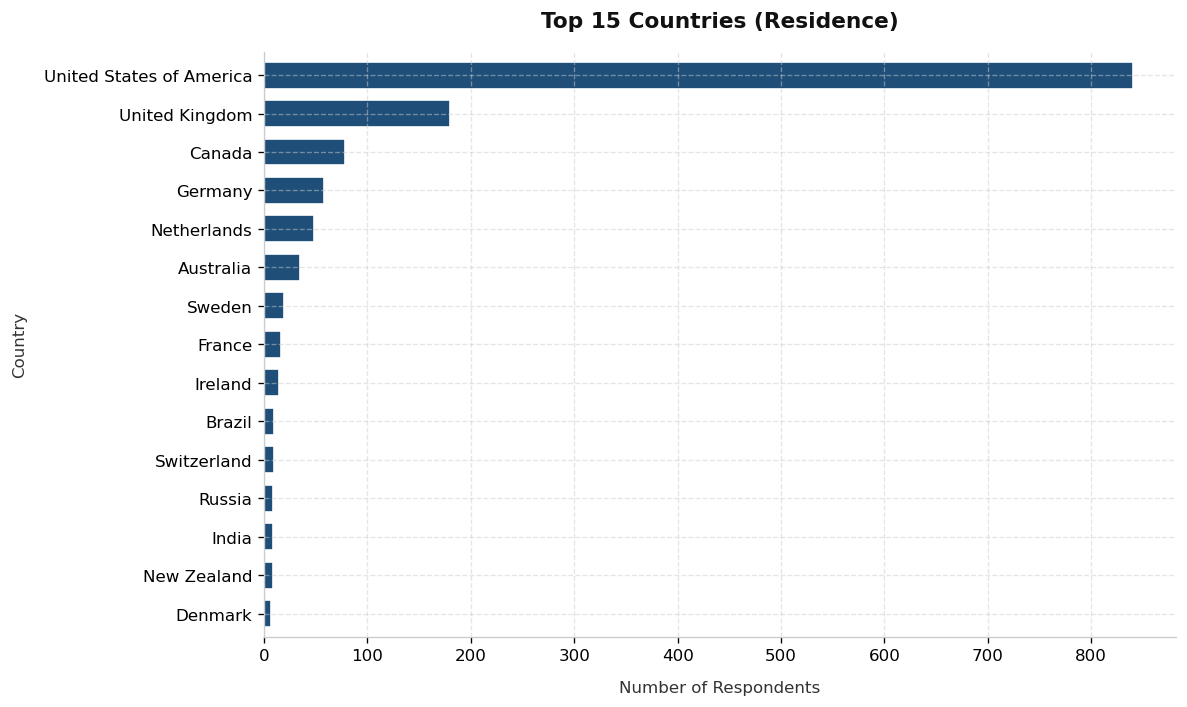

Distinct residence countries: 53
Share of respondents in the top 3 countries: 76.6%


In [34]:
# Cell 27: Distribution of respondents by country of residence
# Top 15 countries as a horizontal bar chart, plus the share held by the top 3
# to quantify how concentrated the sample is.

top_live = df[LIVE].value_counts(dropna=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))

top_live.plot(kind="barh", ax=ax, color=PALETTE["primary"], edgecolor="white", width=0.7)
ax.invert_yaxis()  # keep the top country at the top
ax.set_title("Top 15 Countries (Residence)", fontsize=13, fontweight="bold",
             pad=15, color="#111111")
ax.set_xlabel("Number of Respondents", fontsize=10, labelpad=10, color="#333333")
ax.set_ylabel("Country", fontsize=10, labelpad=10, color="#333333")

for spine in ax.spines.values():
    spine.set_color(PALETTE["grid"])

plt.tight_layout()
save_figure(fig, "01_country_residence.png")
plt.show()
plt.close(fig)

top3_share = df[LIVE].value_counts().head(3).sum() / len(df) * 100
print(f"Distinct residence countries: {df[LIVE].nunique()}")
print(f"Share of respondents in the top 3 countries: {top3_share:.1f}%")

### 10.2 Country of Workplace
The distribution of respondents by workplace country is examined using the same approach.

Comparing the workplace distribution with residence provides context for determining whether the two variables contain overlapping or distinct geographic information.

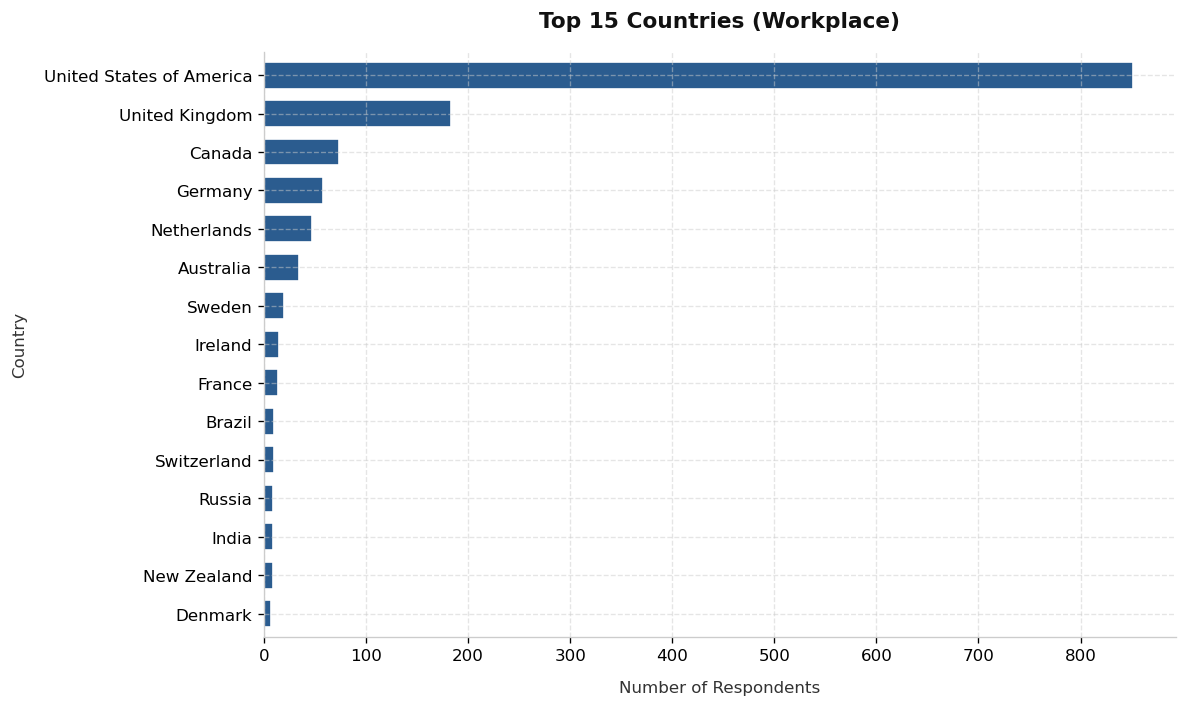

Distinct workplace countries: 53
Share of respondents in the top 3 countries: 77.3%


In [35]:
# Cell 28: Distribution of respondents by workplace country
# Same presentation as Cell 27 so the two figures can be compared directly.

top_work = df[WORK].value_counts(dropna=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))

top_work.plot(kind="barh", ax=ax, color=PALETTE["secondary"], edgecolor="white", width=0.7)
ax.invert_yaxis()
ax.set_title("Top 15 Countries (Workplace)", fontsize=13, fontweight="bold",
             pad=15, color="#111111")
ax.set_xlabel("Number of Respondents", fontsize=10, labelpad=10, color="#333333")
ax.set_ylabel("Country", fontsize=10, labelpad=10, color="#333333")

for spine in ax.spines.values():
    spine.set_color(PALETTE["grid"])

plt.tight_layout()
save_figure(fig, "01_country_workplace.png")
plt.show()
plt.close(fig)

top3_share_work = df[WORK].value_counts().head(3).sum() / len(df) * 100
print(f"Distinct workplace countries: {df[WORK].nunique()}")
print(f"Share of respondents in the top 3 countries: {top3_share_work:.1f}%")

### 10.3 Residence and Workplace Mismatch

Residence and workplace countries are compared for each respondent.

The number of respondents with different residence and workplace countries is calculated, and the most common country pairs are examined.

This provides evidence about how frequently the two geographic variables describe different aspects of respondents' circumstances.

In [36]:
# Cell 29: Residence vs workplace country mismatch
# Count respondents whose two countries differ and list the most common pairs.

mismatch = df[LIVE] != df[WORK]
print(f"Respondents where residence != workplace country: {mismatch.sum()} "
      f"({mismatch.mean() * 100:.1f}% of {len(df)})")

print("\nMost common mismatched (residence, workplace) pairs:")
print(df.loc[mismatch, [LIVE, WORK]].value_counts().head(10).to_string())

Respondents where residence != workplace country: 26 (1.8% of 1433)

Most common mismatched (residence, workplace) pairs:
What country do you live in?  What country do you work in?
Canada                        United States of America        5
United Kingdom                United States of America        2
France                        United Kingdom                  2
United States of America      United Arab Emirates            1
Spain                         United States of America        1
United States of America      Turkey                          1
Netherlands                   United Kingdom                  1
Lithuania                     United Kingdom                  1
Algeria                       United States of America        1
Pakistan                      United States of America        1


# 11. Free-Text Assessment
Open-ended responses require separate consideration because their values cannot be treated as ordinary categorical levels without potentially creating a very high-dimensional representation.

The free-text variables identified earlier are therefore assessed in more detail.

The analysis examines:
 - the number of responses;
 - the number of unique responses;
 - response length; and
 - representative sample responses.

This provides evidence about whether the text fields contain structured information that could reasonably be transformed into model features or whether their treatment should be limited or excluded in the subsequent pipeline.

The sample responses are used for qualitative inspection only and are not used to make conclusions about individual respondents.

### 11.1 Response Count and Uniqueness

The number of available responses and distinct responses is calculated for each identified free-text variable.

A high proportion of unique responses indicates that the field behaves differently from a conventional categorical variable.

In [37]:
# Cell 30: Free-text response counts and uniqueness
# Report responses, unique responses, and the answered share of all 1,433 rows
# (so the denominator is explicit).

for col in FREE_TEXT_COLS:
    s = df[col].dropna()
    print(f"\n--- {col} ---")
    print(f"Responses: {len(s)} ({len(s) / len(df) * 100:.1f}% of all respondents)")
    print(f"Unique responses: {s.nunique()} ({s.nunique() / len(s) * 100:.1f}% of responses)")


--- Why or why not? ---
Responses: 1095 (76.4% of all respondents)
Unique responses: 1085 (99.1% of responses)

--- Why or why not?.1 ---
Responses: 1126 (78.6% of all respondents)
Unique responses: 1080 (95.9% of responses)


### 11.2 Response Length

The length of free-text responses is examined to understand the amount of textual information contained in the variables.

Both typical and maximum response lengths are considered because extremely short and extremely long responses may have different implications for later text processing.

In [38]:
# Cell 31: Free-text response length in words
# Median, quartiles and maximum describe how much text each field really contains.

for col in FREE_TEXT_COLS:
    word_counts = df[col].dropna().str.split().str.len()
    print(f"\n--- {col} (words per response) ---")
    print(word_counts.describe().round(1).to_string())


--- Why or why not? (words per response) ---
count    1095.0
mean       16.1
std        18.1
min         1.0
25%         7.0
50%        13.0
75%        20.0
max       446.0

--- Why or why not?.1 (words per response) ---
count    1126.0
mean       15.7
std        16.4
min         1.0
25%         6.0
50%        11.0
75%        20.0
max       202.0


### 11.3 Sample Responses

A small number of representative responses are displayed to provide qualitative context for the numerical summaries.

These examples are used only to understand the structure and content of the fields, not to generalize from individual responses.

In [39]:
# Cell 32: Random sample of free-text responses (fixed seed for reproducibility)
# Truncated to 150 characters so the output stays readable.

for col in FREE_TEXT_COLS:
    print(f"\n--- {col} ---")
    for text in df[col].dropna().sample(3, random_state=42):
        print(f"  - {text[:150]}")


--- Why or why not? ---
  - I have a physical disability that is not visible. If I don't bring it up, it will make itself known down the line. Better to bring it up when I am in 
  - I have RSI and don't want them to think I'm not worth investing in.
  - Due to increased healthcare cost potential

--- Why or why not?.1 ---
  - A general lack of understanding or sufficient social norms to appropriately respond to such issues.
  - If its relevant.
  - Don't want to set a bad precedent. 


# 12. Categorical Redundancy

After establishing the structure and meaning of the categorical variables, their pairwise associations are examined to identify variables that may contain substantially overlapping information.

Cramér's V is calculated for suitable categorical variables with a limited number of response categories.
The resulting association matrix and strongest observed associations are used as an exploratory diagnostic.

A strong association does not automatically mean that one variable should be removed. Instead, it identifies pairs that require consideration during preprocessing and feature selection because closely related variables may represent overlapping information in the final feature representation.

The analysis therefore treats Cramér's V as evidence for further investigation rather than as an automatic feature-removal rule.

### 12.1 Cramér's V Association Analysis

Cramér's V is calculated between eligible categorical variables to quantify the strength of their association.

The resulting heatmap provides an overview of the association structure, while the strongest pairs are inspected individually.

These results are recorded as potential redundancy or dependency considerations for later feature engineering and feature selection.

Columns included: 15


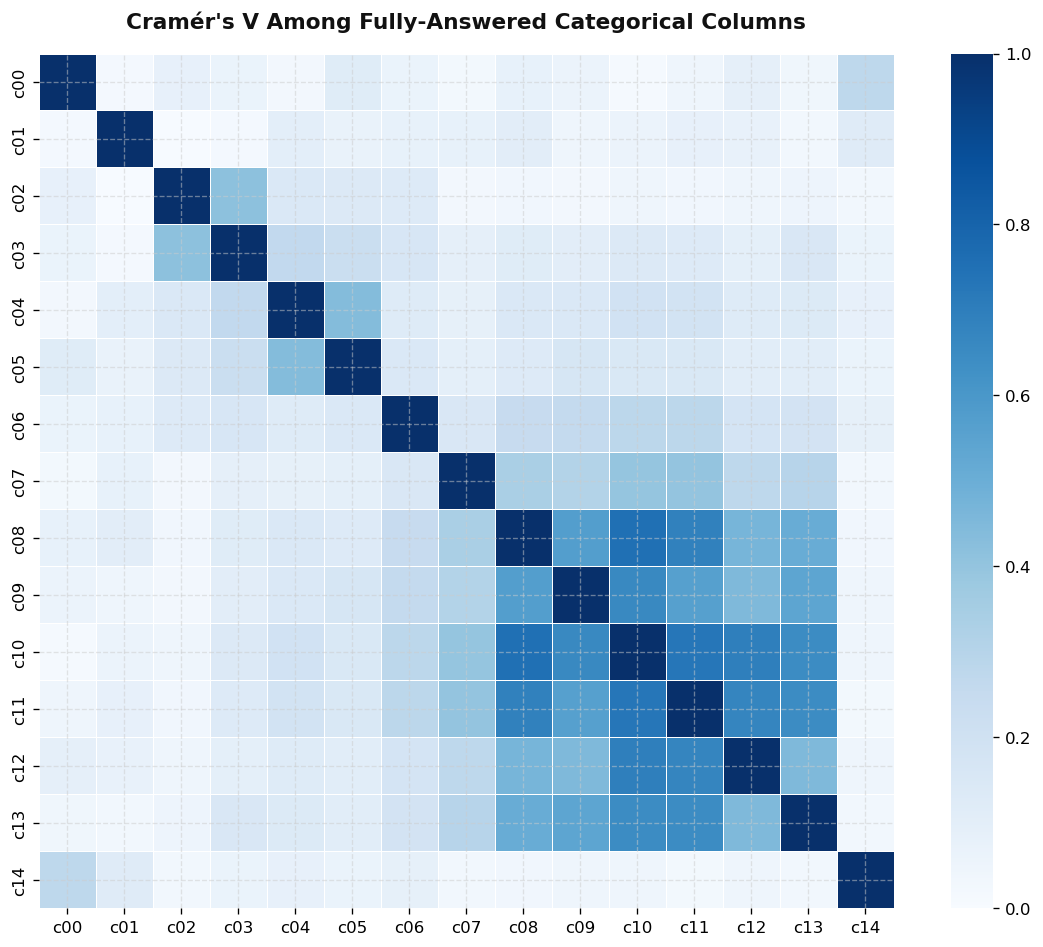

c00  Are you self-employed?
c01  Do you have previous employers?
c02  Would you be willing to bring up a physical health issue with a potential employer in an interview?
c03  Would you bring up a mental health issue with a potential employer in an interview?
c04  Do you feel that being identified as a person with a mental health issue would hurt your career?
c05  Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?
c06  How willing would you be to share with friends and family that you have a mental illness?
c07  Do you have a family history of mental illness?
c08  Have you had a mental health disorder in the past?
c09  Do you currently have a mental health disorder?
c10  Have you been diagnosed with a mental health condition by a medical professional?
c11  Have you ever sought treatment for a mental health issue from a mental health professional?
c12  If you have a mental health issue, do you feel that it interf

In [40]:
# Cell 33: Cramér's V among fully-answered categorical columns
# Restrict to columns with no missing values and at most 8 categories so the
# matrix is complete and the contingency tables are meaningful.
# V ranges from 0 (no association) to 1 (perfect association).


def cramers_v(a, b):
    """Association between two categorical series (0 = none, 1 = perfect)."""
    table = pd.crosstab(a, b)
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.values.sum()
    return np.sqrt(chi2 / (n * (min(table.shape) - 1)))


cat_cols = [c for c in df.columns
            if df[c].nunique() <= 8 and df[c].isna().sum() == 0]
print(f"Columns included: {len(cat_cols)}")

V = pd.DataFrame(
    {a: {b: cramers_v(df[a], df[b]) for b in cat_cols} for a in cat_cols}
)

# Short labels keep the heatmap readable; the lookup is printed below
short = {c: f"c{i:02d}" for i, c in enumerate(cat_cols)}
V_plot = V.rename(index=short, columns=short)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(V_plot, cmap="Blues", vmin=0, vmax=1, square=True,
            linewidths=0.3, linecolor="#ffffff", ax=ax)
ax.set_title("Cramér's V Among Fully-Answered Categorical Columns",
             fontsize=13, fontweight="bold", pad=15, color="#111111")

plt.tight_layout()
save_figure(fig, "01_cramers_v_heatmap.png")
plt.show()
plt.close(fig)

# Lookup table for the short labels
for col, label in short.items():
    print(f"{label}  {col}")

In [41]:
# Cell 34: Strongest associated pairs
# Use the upper triangle only so each pair appears once (no self-pairs, no duplicates).

upper = V.where(np.triu(np.ones(V.shape), k=1).astype(bool)).stack()
print("Top 15 most associated pairs (Cramér's V):\n")
print(upper.sort_values(ascending=False).head(15).round(3).to_string())

Top 15 most associated pairs (Cramér's V):

Have you had a mental health disorder in the past?                                                                Have you been diagnosed with a mental health condition by a medical professional?                                       0.753
Have you been diagnosed with a mental health condition by a medical professional?                                 Have you ever sought treatment for a mental health issue from a mental health professional?                             0.728
                                                                                                                  If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?        0.696
Have you had a mental health disorder in the past?                                                                Have you ever sought treatment for a mental health issue from a mental health professional?                             0.

In [42]:
# Cell 34b: Associations of the stigma, routing and remote-work variables
# Cell 34 only prints the 15 strongest pairs. This prints each selected variable's
# strongest association with any other fully answered categorical variable.

check_cols = [SELF, PREV, CAREER,
              "Do you work remotely?",
              "Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?",
              "Would you bring up a mental health issue with a potential employer in an interview?"]

for col in check_cols:
    s = V[col].drop(col).sort_values(ascending=False)
    print(f"{col[:70]}\n   strongest: {s.index[0][:60]} (V = {s.iloc[0]:.3f})\n")

Are you self-employed?
   strongest: Do you work remotely? (V = 0.277)

Do you have previous employers?
   strongest: Do you work remotely? (V = 0.124)

Do you feel that being identified as a person with a mental health iss
   strongest: Do you think that team members/co-workers would view you mor (V = 0.441)

Do you work remotely?
   strongest: Are you self-employed? (V = 0.277)

Do you think that team members/co-workers would view you more negative
   strongest: Do you feel that being identified as a person with a mental  (V = 0.441)

Would you bring up a mental health issue with a potential employer in 
   strongest: Would you be willing to bring up a physical health issue wit (V = 0.418)



# 13. EDA Summary and Implications for Notebook 02

This section consolidates the findings of the exploratory analysis. Every finding follows the structure **finding → evidence → implication**, and the evidence reference points to the section and cell that produced it. Percentages state their denominators. Numbers refer to all 1,433 respondents unless stated otherwise.

The purpose of this section is not to apply preprocessing. It records the evidence and the direction it supports, and turns every open issue into a specific question for Notebook 02.

---

## 13.1 Dataset Dimensions and Storage (Cells 2–5)

- **1,433 respondents × 63 survey questions.** No duplicate rows (Cell 5).
- **Storage types:** 56 text columns (pandas `str` dtype), 4 `int64` and 3 `float64`. Storage types do not describe analytical structure. The response-type taxonomy (Cell 18) governs how each variable is treated.

---

## 13.2 Missingness and Survey Routing (Sections 5.1–5.3, Cells 6–14)

**Observed.** 19 columns have no missing values, none is entirely missing (the highest missingness is 90.0%), and the other 44 have partial missingness. Missingness is predominantly structural: it follows from survey routing and is not random data loss.

**Validated primary routing (Cells 8b, 11–13).** Each hypothesis was tested for every respondent and holds without exception:

| Gate | Questions affected | Respondents affected | Result |
|---|---|---|---|
| Self-employed = 1 | 13 of the 15 current-employer questions are missing for exactly these respondents (the other two, tech role and coverage options, have extra gating) | 287 (20.0%) | Holds for all 1,433 (Cell 11) |
| Self-employed = 0 | 6 of the 8 self-employed-only questions are missing for exactly these respondents (the other two are follow-ups) | 1,146 (80.0%) | Perfect gate in Cell 8b |
| Previous employers = 0 | All 11 previous-employer questions | 169 (11.8%) | Holds for all 1,433 (Cell 12) |
| Employer is tech | Tech-role question is answered only when the employer is **not** primarily a tech company | Answered by 263 of 1,146 employed respondents (22.9%); missing for 883 tech employers and 287 self-employed | Holds for all 1,433 (Cell 13) |

Of the 263 respondents who answered the tech-role question, 248 (94.3%) report a tech-related role.

**Validated second-tier routing (Cells 8b, 8c).**

- The percentage-of-work-time question is gated by the productivity question: 204 answered, equal to the 204 "Yes" answers (83 of the 287 self-employed respondents did not see it).
- The US-state questions are answered by exactly the 840 respondents living in the USA and the 851 working there, and by nobody else.
- The three condition questions are answered only by the respondents they apply to, and by no others:

| Condition question | Eligible respondents | Answered | Left blank |
|---|---|---|---|
| "Diagnosed with" (current disorder = Yes) | 575 | 568 | 7 (1.2%) |
| "Believe you have" (current disorder = Maybe) | 327 | 322 | 5 (1.5%) |
| "Were diagnosed with" (diagnosed by a professional = Yes) | 716 | 711 | 5 (0.7%) |

These columns therefore combine structural missingness (question not shown) with a small amount of item non-response (17 eligible blanks).

The other "perfect gates" reported by Cell 8b for the employer and self-employed blocks are the complementary blocks themselves, not additional routing logic.

**No gate identified.** Six columns have no identified gate: the coverage-options question (420 missing, 29.3%; 133 of the 1,146 employed respondents did not answer it), the client-impact follow-up (1,289 missing; 143 of the 287 self-employed respondents did not answer it), both "Why or why not?" fields (338 and 307 missing), the unsupportive-response question (89 missing), and the observation follow-up (776 missing). Cell 8b only tests candidate gates with at most 8 categories and requires them to be perfect, so "none found" means "not identified", not "random".

**Unexplained missingness (Cell 14).** 89 respondents (6.2%) skipped the unsupportive-response question, and they are spread across all four routing groups (39 employed with previous employers, 23 self-employed with, 14 self-employed without, 13 employed without), so routing does not explain them. Gender is missing for 3 respondents (0.2%), all employed with previous employers.

**Implication.** A structurally missing value means "question not shown" and must not be imputed with a statistic. It needs exclusion of the variable, a dedicated "not asked" state, or a population restriction. Conventional treatment applies only to the unexplained cases (89 and 3) and to the 17 eligible blanks in the condition questions.

---

## 13.3 Always-Answered Variables (Cell 9)

19 questions were answered by every respondent regardless of routing:

| Group | Variables |
|---|---|
| Routing gates (2) | self-employed, previous employers |
| Personal mental-health status (5) | current disorder, past disorder, family history, diagnosed by a professional, sought treatment |
| Work interference (2) | interference when treated, interference when not treated |
| Stigma and disclosure attitudes (5) | would bring up a physical health issue in an interview, would bring up a mental health issue in an interview, being identified would hurt career, co-workers would view negatively, willingness to share with friends and family |
| Demographics and work context (5) | age, country of residence, country of work, work position, works remotely |

**Implication.** These variables are a safe core because they have no structural missingness. None of them describes the employer (benefits, resources, anonymity, leave), which is the part HR can change. Those variables exist only in the employer block and are available for employed respondents only (see 13.8 and 13.10).

---

## 13.4 Response-Type Taxonomy (Sections 6–7.0, Cells 15–18)

| Type | Count | Notes |
|---|---|---|
| Categorical, low cardinality | 38 | 3 to 6 response options |
| Binary | 8 | Stored in three different ways (see below) |
| Ordinal candidate | 5 | Manual designation: both interference questions, leave difficulty, willingness to share, percentage of work time affected |
| High cardinality | 5 | Gender (70 values), two country columns (53 each), two US-state columns (47 and 48) |
| Multi-label | 4 | Work position and the three condition columns (13.5) |
| Free text | 2 | See 13.6 |
| Continuous numeric | 1 | Age |

**Inconsistent binary encodings.** Integers (self-employed, previous employers, sought treatment), floats with missing values (employer is tech, tech role, medical coverage), and Yes/No text (diagnosed by a professional, observed negative consequences).

**Corrections to the first-pass notes.** Diagnosed by a professional is stored as Yes / No text, not 0/1. Family history has the answers Yes / No / I don't know, not Yes / No / Maybe.

**Ordinal candidates** mix ordered levels with off-scale answers such as "I don't know" and "Not applicable to me". Many other questions use Yes / No / "I don't know" or Yes / No / Maybe, where "I don't know" and "Maybe" are not clearly positions on a scale.

**Pitfalls found while building the taxonomy.** pandas' `str` dtype is not equal to `object`, so a check written for `object` silently missed all text columns. A single stray pipe character in the gender field ("M|") would have classified gender as multi-label, so the multi-label rule requires the separator in at least 5% of responses.

**Implication.** Binary columns need one common 0/1 encoding. Ordinal columns need an explicit order and a rule for off-scale answers.

---

## 13.5 Multi-Label Columns (Section 7.1, Cell 19)

| Column | Raw combinations | Distinct labels |
|---|---|---|
| Work position | 264 | 12 |
| Conditions: "diagnosed with" (current = Yes) | 128 | 33 |
| Conditions: "believe you have" (current = Maybe) | 99 | 23 |
| Conditions: "were diagnosed with" (professional = Yes) | 116 | 34 |

**Work position.** There are 2,692 label mentions across 1,433 respondents (about 1.9 roles per person). Back-end Developer (737, 51.4% of respondents) and Front-end Developer (502, 35.0%) dominate. "Other" (187, 13.0%) is a catch-all, and the smallest label (HR) has 12 mentions.

**Conditions.** In each condition column, 12 standard labels have at least 6 mentions, and Mood Disorder and Anxiety Disorder dominate all three columns. The remaining labels (21, 11 and 22) occur at most 3 times each. They are free-text write-ins and alternative spellings of standard labels (for example a plain "Depression" next to "Mood Disorder", or "PDD-NOS" next to the full name).

**Implication.** Multi-label columns should become indicator columns for the frequent labels, with one "other" indicator for the rest. The three condition columns overlap in content and have different gates, so how to combine them needs a decision.

---

## 13.6 Free-Text Variables (Section 7.2 and Section 11, Cells 20, 30–32)

| Field | Responses | Unique | Median words | 75th percentile | Mean | Maximum |
|---|---|---|---|---|---|---|
| "Why or why not?" (physical health) | 1,095 (76.4%) | 1,085 (99.1%) | 13 | 20 | 16.1 | 446 |
| "Why or why not?.1" (mental health) | 1,126 (78.6%) | 1,080 (95.9%) | 11 | 20 | 15.7 | 202 |

Answers are short, and almost every answer is unique. Some answers in the second field refer back to the first ("same reason"), so they cannot be interpreted independently. The sampled answers describe individual health circumstances, so individual responses are not quoted in this notebook's conclusions or in the report.

**Implication.** Categorical encoding is meaningless for these fields, and short, sparse responses would give weak text features. Exclude them from the clustering features. They may be used afterwards to describe clusters (for example with TF-IDF keywords per cluster).

---

## 13.7 Data Quality: Age and Gender (Sections 7.3–7.4, Cells 21–23)

### Age (n = 1,433, no missing)

Median 33, interquartile range 28 to 39, mean 34.3. The minimum (3) and maximum (323) inflate the standard deviation to 11.3.

| Band | Count | Assessment |
|---|---|---|
| [0, 15) | 1 | Clearly invalid (age 3) |
| [15, 18) | 2 | Unusual but possible |
| [70, 100) | 3 | Plausible but uncommon |
| [100, 400) | 1 | Clearly invalid (age 323) |

7 respondents (0.5%) fall into these bands, and the other 1,426 are aged 18 to 69.

### Gender (1,430 answered, 3 missing)

There are 70 raw values, falling to 54 after trimming spaces and lowercasing, so 16 variants are purely formatting. Four spellings of "male" (Male, male, M, m) cover 1,024 respondents (71.5% of 1,433) and four of "female" (Female, female, F, f) cover 309 (21.6%), together 93.0%. The remaining 97 answered responses mix further spellings of male and female (for example with trailing spaces), other gender identities, abbreviations that cannot be interpreted without a rule (for example "AFAB", "fm"), descriptive answers, jokes and refusals. One response contains a stray pipe character ("M|").

The earlier rough group sizes (about 1,060 male, 340 female, 20 non-binary or other, 10 ambiguous) came from a manual tally, not from a cell, and are replaced by the computed figures above. Final group counts will be computed in Notebook 02 once the normalisation rules are fixed.

**Implication.** Only the two clearly invalid ages need an explicit rule; the 15–17 and 70–99 groups need a decision. Gender can be reduced to a small number of groups, but the small remaining groups cannot support separate clusters, so its role (clustering feature or description of clusters only) must be decided deliberately.

---

## 13.8 Population (Section 8, Cells 24, 25, 25c)

1,146 respondents (80.0%) are employed and 287 (20.0%) are self-employed. Chi-square tests of independence between employment group and the four questions both groups answered:

| Question | chi2 | p | Cramér's V | Significant after Bonferroni (threshold 0.0125) |
|---|---|---|---|---|
| Current disorder | 5.07 | 0.079 | 0.059 | No |
| Past disorder | 9.03 | 0.011 | 0.079 | **Yes** |
| Family history | 1.05 | 0.590 | 0.027 | No |
| Career stigma | 1.39 | 0.846 | 0.031 | No |

Only past disorder differs: self-employed respondents answered "No" less often (25.1% vs 33.1%, a difference of 8.0 percentage points) and "Maybe" more often (21.6% vs 16.1%). All effect sizes are small. Family-history and career-stigma answers are statistically indistinguishable between the groups.

Self-employed respondents were never shown the employer questions (benefits, resources, anonymity, leave), which are the variables most relevant to employer-side HR measures. Including them would require either dropping those variables or carrying 287 respondents who are missing all of them.

Self-employment is more strongly associated with working remotely (Cramér's V = 0.277, Cell 34b) than with any of the four mental-health questions above. The direction and significance of this association were not examined.

**Implication.** Restrict the analysis to employed respondents (n = 1,146). Record as a limitation that the results describe employees, not the full survey population, and that the slightly different past-disorder answers of the self-employed are not represented.

---

## 13.9 Response Semantics: "Not Applicable to Me" (Section 9, Cells 16 and 26)

**Where it appears (Cell 16).** Both interference questions (557 and 468 respondents, 38.9% and 32.7% of 1,433), the willingness-to-share question (112, worded "I do not have a mental illness"), and four self-employed-only questions (101, 111, 133 and 31 of 287). A different wording, "N/A (not currently aware)", is the most frequent answer to the previous-employer awareness question (582 of 1,264, 46.0%). Only the two interference questions were cross-tabulated against disorder status.

| Current disorder | "Not applicable" (interference when treated) | "Not applicable" (interference when not treated) |
|---|---|---|
| No | 403 / 531 = 75.9% | 401 / 531 = 75.5% |
| Maybe | 118 / 327 = 36.1% | 53 / 327 = 16.2% |
| Yes | 36 / 575 = 6.3% | 14 / 575 = 2.4% |

**Implication.** In the interference questions, "Not applicable" mainly means "no condition, so no interference". It carries real information and must not be converted to missing. It should be encoded as the lowest-interference level or as a separate indicator. The 36 and 14 respondents with a current disorder who chose it are a small group that needs a deliberate rule. The other occurrences have different meanings and need their own check.

---

## 13.10 Employer-Side and Attitude Distributions (Cell 16)

These descriptive distributions cover the variables most relevant to HR measures. Employer-side questions refer to the 1,146 employed respondents; attitude and status questions to all 1,433. No test is applied.

**Employer-side questions (n = 1,146).**

| Question | Answers |
|---|---|
| Employer provides mental health benefits | Yes 531 (46.3%), I don't know 319 (27.8%), No 213 (18.6%), not eligible 83 (7.2%) |
| Employer offers resources about mental health | No 531 (46.3%), I don't know 320 (27.9%), Yes 295 (25.7%) |
| Anonymity is protected when using treatment resources | I don't know 742 (64.7%), Yes 320 (27.9%), No 84 (7.3%) |
| Employer has formally discussed mental health | No 813 (70.9%), Yes 230 (20.1%), I don't know 103 (9.0%) |
| Employer takes mental health as seriously as physical health | I don't know 493 (43.0%), Yes 350 (30.5%), No 303 (26.4%) |
| Asking for medical leave would be | very or somewhat easy 501 (43.7%), very or somewhat difficult 317 (27.7%), neither 178 (15.5%), I don't know 150 (13.1%) |
| Knows the options under employer coverage (1,013 answered) | No 354 (34.9%), not sure 352 (34.7%), Yes 307 (30.3%) |

"I don't know" is the most frequent answer to two of the six fully answered employer questions (anonymity, taking mental health seriously) and the second most frequent to two more (benefits, resources). It is therefore a large, substantive answer on exactly the variables an employer controls. It may indicate that employees are unaware of what their employer provides; this interpretation should be tested in the cluster profiles.

**Stigma and disclosure attitudes (n = 1,433).**

| Question | Answers |
|---|---|
| Being identified with a mental health issue would hurt career | Maybe 588 (41.0%), yes I think it would 563 (39.3%), yes it has 105 (7.3%), no I don't think it would 147 (10.3%), no it has not 30 (2.1%) |
| Would bring up a mental health issue in an interview | No 883 (61.6%), maybe 438 (30.6%), yes 112 (7.8%) |
| Would bring up a physical health issue in an interview | Maybe 633 (44.2%), no 441 (30.8%), yes 359 (25.1%) |
| Co-workers would view me more negatively | Maybe 591 (41.2%), yes I think they would 403 (28.1%), no I don't think they would 348 (24.3%), no they do not 49 (3.4%), yes they do 42 (2.9%) |

In total, 1,256 respondents (87.7%) answered "maybe" or "yes" (including "yes, it has") to the career question. Respondents were about twice as likely to rule out raising a mental health issue in an interview (61.6%) as a physical one (30.8%).

**Personal status (n = 1,433).** Current disorder: yes 575 (40.1%), maybe 327 (22.8%), no 531 (37.1%). Diagnosed by a professional: 716 (50.0%). Sought treatment: 839 (58.5%). These figures describe survey respondents and cannot be generalised to a workforce.

**Implication.** These distributions are descriptive context, not cluster results. The large "I don't know" share means that answer needs its own handling in Notebook 02 (open question 10), because it cannot be treated as missing or placed on an ordered scale without a decision.

---

## 13.11 Geography (Section 10, Cells 8c, 27–29)

- 53 residence countries and 53 workplace countries. The USA alone accounts for 840 respondents by residence (58.6%) and 851 by workplace (59.4%). The three largest countries hold 76.6% and 77.3%.
- Only 26 respondents (1.8%) live in a different country from where they work, most often Canada with a US workplace (5).
- The US-state questions are fully determined by country (Cell 8c).

**Implication.** Residence and workplace country carry almost the same information, so only one is needed. Country needs grouping (for example the main countries plus "other") instead of one-hot encoding. The US-state columns are redundant with country and structurally missing for about 41% of respondents, so they are unlikely to be useful as clustering features. The concentration of the sample in a few countries is a limitation on how far the results generalise.

---

## 13.12 Categorical Redundancy (Section 12, Cells 33–34b)

The analysis covers the fully answered categorical columns (no missing values, at most 8 categories). **All 15 strongest pairs consist of six clinical-status variables**: past disorder, current disorder, diagnosed by a professional, sought treatment, and the two interference questions. Cramér's V ranges from 0.451 to 0.753 across these 15 pairs:

| Pair | V |
|---|---|
| Past disorder and diagnosed by a professional | 0.753 |
| Diagnosed and sought treatment | 0.728 |
| Diagnosed and interference when treated | 0.696 |
| Past disorder and sought treatment | 0.690 |
| Sought treatment and interference when treated | 0.673 |
| Current disorder and diagnosed | 0.659 |

The stigma and disclosure attitudes form a separate, weaker group. Their strongest associations are within the group: being identified as a person with a mental health issue would hurt career with co-workers would view me more negatively (V = 0.441), and would bring up a mental health issue in an interview with would bring up a physical health issue (V = 0.418). Both are just below the 15th-strongest pair of the whole analysis (0.451). The strongest association of each routing variable is weak: self-employed with works remotely (V = 0.277) and previous employers with works remotely (V = 0.124).

Part of the interference association comes from the "Not applicable" semantics in 13.9.

**Implication.** The six clinical-status variables are closely related. If all are used for clustering, this topic carries six times the weight of any other, and clusters will mainly separate people by clinical status. Whether to use them, or to reduce them to one or two summary features, must be decided deliberately. The two moderately associated stigma pairs measure related constructs (fear of consequences at work, and willingness to disclose a mental versus a physical issue). They are weaker than the clinical-status cluster, but overlap should be checked before feature selection; the mental-versus-physical disclosure pair could also be combined into a single "disclosure gap" measure.

---

## 13.13 Implications for Notebook 02

| Decision area | Finding | Supported direction |
|---|---|---|
| Population | Self-employed respondents lack the employer block | Employed respondents only (n = 1,146); record as a limitation |
| Structural missing values | Missing means "question not shown" | No statistical imputation; exclude the variable or add a "not asked" state |
| Unexplained missing values | 89 unsupportive-response, 3 gender, 17 condition blanks | Treat as non-response and document |
| Age | 2 clearly invalid values; 5 edge cases | Mark the 2 invalid values; decide on the edge cases and on dropping vs median imputation |
| Gender | 70 raw values; 93.0% in eight standard spellings | Define normalisation rules; decide whether it is a clustering feature |
| Binary variables | Three storage forms | One common 0/1 encoding |
| Ordinal variables and "Not applicable" | Off-scale answers mixed into ordered scales | "Not applicable" as the lowest interference level in the interference questions; a rule for "I don't know" and "Maybe" |
| Free text | 99.1% and 95.9% unique, short | Exclude from clustering; possible use for describing clusters |
| Geography | 1.8% live elsewhere than they work | One grouped country variable; drop the US-state columns |
| Multi-label columns | 264 to 12 and 128, 99, 116 to 33, 23, 34 | Indicators for frequent labels plus one "other" |
| Condition columns | Three overlapping columns with different gates | Decide between union, separate use, or a single summary |
| Clinical-status variables | Six variables, V from 0.45 to 0.75 | Select or summarise |
| Feature roles | Case study goal is HR leverage points | Employer-side HR variables and stigma attitudes as clustering candidates; clinical status and demographics to describe clusters |
| Stigma and disclosure attitudes | Two moderately associated pairs (V = 0.44 and 0.42) | Keep as a separate group; check overlap before feature selection |

---

## 13.14 Open Questions for Notebook 02

1. Which age bounds are defensible, and are the 2 respondents aged 15–17 and the 3 aged 70–99 kept?
2. Which normalisation rules apply to ambiguous gender entries, and does gender enter the clustering or only the description of clusters?
3. Is the employed-only population (n = 1,146) confirmed?
4. How are the three condition columns reconciled: union, separate columns, or one summary?
5. How are the six closely related clinical-status variables handled: all, a subset, or a summary?
6. Is country retained, and if so grouped how?
7. How is work position encoded, and is "Other" a label or unknown?
8. Is the previous-employer block (11 questions, structurally missing for respondents with no previous employer) used, given its structural missingness?
9. How are the six columns without an identified gate (coverage options and the others in 13.2) treated after the population restriction?
10. How are "I don't know" and "Maybe" placed relative to the ordered answers? (13.10 shows that "I don't know" is the most frequent answer to two employer-side questions.)
11. Which variables form the clusters and which only describe them? This follows from the goal of identifying leverage points for HR measures, not from the data alone, and must be argued in the report.

**Limitations of this EDA.** The gate search (Cell 8b) only tests gates with at most 8 categories and requires them to be perfect. The redundancy analysis (Cells 33–34b) covers only fully answered categorical variables, so it does not assess the employer questions, which have missing values. The population comparison covers four questions and effect sizes are small. Only the interference questions were checked for the meaning of "Not applicable". The distributions in 13.10 are descriptive and untested. Missingness after restricting to employed respondents was not examined in this notebook; it is the first check in Notebook 02.